# 03 — Block Factor Model: Specification Validation

Validates whether the **three-block factor structure** (1 latent factor per economic block) is
statistically justified and whether each factor is well-identified within its block.

**Methodological frame:** this is *not* a Bai–Ng exercise to *choose* the number of factors.
The 3-block structure (real / financial / nominal) is imposed by **economic design** for
interpretability. The question here is:
> *Do the 3 imposed blocks produce genuinely distinct, well-identified latent states,
> each explaining its own block better than the others?*

**Data source:** `data/processed/<CONFIG>/fit_dfm_result.npz` — in-sample EM optimum
(θ★, full history). Set `CONFIG` in the setup cell to `"small"` (20 series) or `"big"` (50 series).

| Analysis | Quantity | Question answered |
|---|---|---|
| 1 | R² own-block | Does each factor explain its block? |
| 2 | Cross-loading R² | Does each factor explain *other* blocks? |
| 3 | Factor correlation | Are factors co-moving or independent? |
| 4 | PCA of factors | Do 3 factors span a 3-D space? |
| 5 | VAR dynamics | Which factor is persistent? Is the system stable? |
| 6 | Variance decomposition | How much panel variance do factors capture? |
| 7 | Residual correlation | Is there unexplained common structure? |
| 8 | Small vs Big comparison | Does the structure hold at both scales? |

In [12]:
import sys, os, pathlib, warnings
warnings.filterwarnings("ignore")

# ── CONFIG SWITCH ──────────────────────────────────────────────────────────────
CONFIG = "big"   # change to "big" for the extended 50-series dataset

# ── project root ───────────────────────────────────────────────────────────────
def _find_root():
    p = pathlib.Path(os.getcwd()).resolve()
    for _ in range(6):
        if (p / "src").is_dir() and (p / "data").is_dir():
            return str(p)
        p = p.parent
    raise RuntimeError("Cannot find project root — launch Jupyter from project dir.")

project_root = _find_root()
sys.path.insert(0, os.path.join(project_root, "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
def _np_pca(X):
    """PCA via eigendecomposition of the covariance matrix (no sklearn needed)."""
    Xc = X - X.mean(axis=0)
    cov = np.cov(Xc.T)
    if Xc.shape[1] == 1:
        return np.array([1.0]), Xc, np.array([[1.0]]), np.var(Xc[:,0], ddof=1, keepdims=True)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    eigvals = np.maximum(eigvals[idx], 0.0)
    eigvecs = eigvecs[:, idx]
    total   = eigvals.sum()
    evr     = eigvals / total if total > 0 else eigvals
    scores  = Xc @ eigvecs
    return evr, scores, eigvecs.T, eigvals

from scipy import stats as sp_stats
from IPython.display import display
from data_loader import load_config

# ── load config ────────────────────────────────────────────────────────────────
cfg        = load_config(CONFIG)
ORDERED_COLS = cfg["ORDERED_COLS"]
BLOCK      = cfg["BLOCK"]
FREQ       = cfg["FREQ"]
M          = len(ORDERED_COLS)

BLOCKS         = ["real", "financial", "other"]
FACTOR_LABELS  = ["Real $f^R_t$", "Financial $f^F_t$", "Nominal $f^N_t$"]
FACTOR_SHORT   = ["real", "financial", "nominal"]
block_colors   = {"real": "steelblue", "financial": "darkorange", "other": "seagreen"}
factor_colors  = ["steelblue", "darkorange", "seagreen"]
cols_by_block  = {b: [c for c in ORDERED_COLS if BLOCK[c] == b] for b in BLOCKS}

# ── load CSV and standardise ───────────────────────────────────────────────────
csv_path = os.path.join(project_root, "data", "processed", f"dataset_{CONFIG}.csv")
df_raw   = pd.read_csv(csv_path, index_col=0, parse_dates=True)

df_std = df_raw.copy()
for col in ORDERED_COLS:
    s = df_raw[col].dropna()
    df_std[col] = (df_raw[col] - s.mean()) / s.std()

# ── load NPZ ───────────────────────────────────────────────────────────────────
npz_path = os.path.join(project_root, "data", "processed", CONFIG, "fit_dfm_result.npz")
res = np.load(npz_path, allow_pickle=True)

T      = int(res["T"])
r      = int(res["r"])
Lambda = res["theta__Lambda"]          # (M, 3)
A_mat  = res["theta__A"]               # (3, 3)
Q_mat  = res["theta__Q"]               # (3, 3)
R_idio = res["theta__R"]               # (M,)
fitted = res["fitted_values_raw"]      # (T, M)  — standardised scale

# current-period factors from Kalman smoother (companion state: [f_t, f_{t-1}, ..., f_{t-4}])
F_raw  = res["f_smooth"][:, :3]       # (T, 3) before sign flip

sign_flips = np.array([
    int(res["sign_flip__real"]),
    int(res["sign_flip__financial"]),
    int(res["sign_flip__other"]),
], dtype=float)
F      = F_raw * sign_flips            # sign-flipped: positive = expansion / tightening / inflation
Lambda_signed = Lambda * sign_flips    # consistent sign convention on loadings

dates  = df_raw.index[:T]

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.titlesize": 9})
sns.set_theme(style="whitegrid")

print(f"Config      : {CONFIG}  ({M} series,  T={T} months)")
print(f"Factors     : {r}  (real / financial / nominal)")
print(f"Sample      : {dates[0].date()}  →  {dates[-1].date()}")
print(f"Converged   : {bool(res['converged'])} in {int(res['n_iter'])} iterations")
print(f"nu_u = {float(res['theta__nu_u']):.3f}   nu_eps = {float(res['theta__nu_eps']):.3f}")
print(f"Sign flips  : real={int(sign_flips[0]):+d}  fin={int(sign_flips[1]):+d}  nom={int(sign_flips[2]):+d}")
print("Setup complete.")

Config      : big  (50 series,  T=498 months)
Factors     : 3  (real / financial / nominal)
Sample      : 1985-01-31  →  2026-06-30
Converged   : True in 32 iterations
nu_u = 4.516   nu_eps = 7.006
Sign flips  : real=+1  fin=-1  nom=-1
Setup complete.


## 0. Smoothed Factor Time Series

Before the formal analyses, plot the three smoothed factors over the full sample.
Grey bands mark the three most recent NBER recessions (2001, 2008–09, 2020).

Sign convention after flipping:
- **Real factor** (positive = above-trend real activity)
- **Financial factor** (positive = financial ease / risk-on)
- **Nominal factor** (positive = above-trend inflation / depreciation)

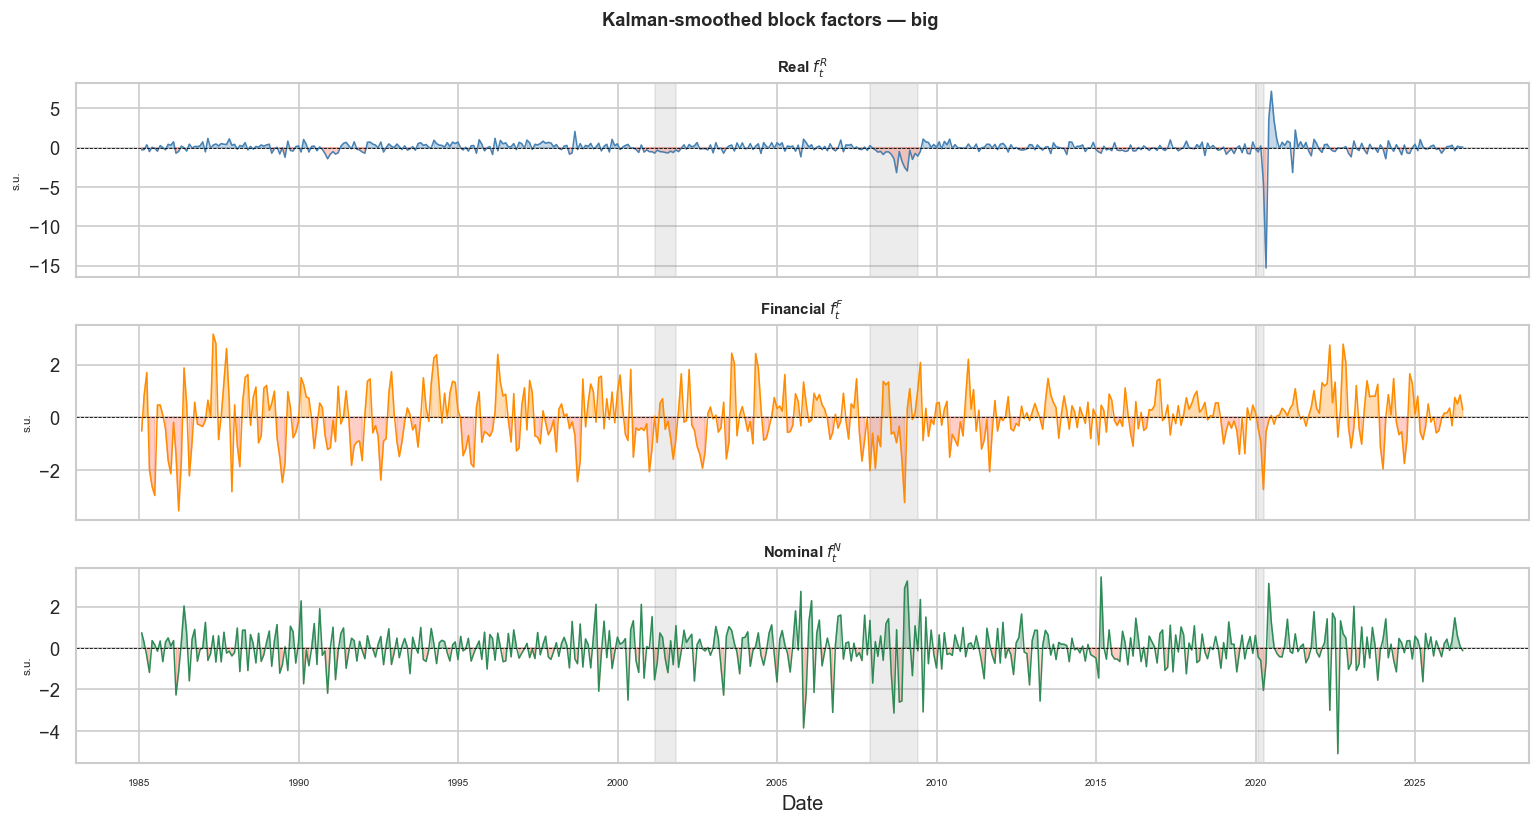

In [13]:
recessions = [
    ("2001-03-01", "2001-11-01"),
    ("2007-12-01", "2009-06-01"),
    ("2020-02-01", "2020-04-01"),
]

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
for ax, j, lbl, col in zip(axes, range(3), FACTOR_LABELS, factor_colors):
    ax.fill_between(dates, F[:, j], 0,
                    where=(F[:, j] >= 0), alpha=0.3, color=col)
    ax.fill_between(dates, F[:, j], 0,
                    where=(F[:, j] < 0),  alpha=0.3, color="tomato")
    ax.plot(dates, F[:, j], color=col, linewidth=0.9)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    for s, e in recessions:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.15, color="gray")
    ax.set_title(lbl, fontsize=9, fontweight="bold")
    ax.set_ylabel("s.u.", fontsize=7)
    ax.tick_params(axis="x", labelsize=6)

axes[-1].set_xlabel("Date")
fig.suptitle(f"Kalman-smoothed block factors — {CONFIG}", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

## 1. R² Per Block — Own-Factor Fit

For each series $y_i$ in block $b$, compute the in-sample $R^2$ against the block factor $f^b$:

$$R^2_i = 1 - \frac{\sum_t (y_{it} - \hat{y}_{it})^2}{\sum_t (y_{it} - \bar{y}_i)^2},
\quad \hat{y}_{it} = \lambda_i \, f^b_t$$

where $\hat{y}_{it}$ comes directly from `fitted_values_raw` (Lambda @ F, standardised scale).

**What to look for:** high R² within each block confirms that the single block factor
captures the common variation of its members. Low R² in a block suggests either
(a) heterogeneous series in that block, or (b) a latent factor that does not align well.

R² summary by block (big):
           count   mean    std  min    25%    50%    75%    max
block                                                          
financial   18.0  0.246  0.361  0.0  0.005  0.022  0.385  0.997
other       10.0  0.338  0.334  0.0  0.082  0.252  0.438  0.960
real        22.0  0.389  0.373  0.0  0.037  0.257  0.791  0.982



,block,lambda_own,R2_own
GS5,financial,0.9919,0.9974
GS10,financial,0.9620,0.9378
GS2,financial,0.9306,0.8652
AAA,financial,0.8295,0.6366
BAA,financial,0.7291,0.4168
TB3MS,financial,0.4870,0.2895
T1YFFM,financial,0.3787,0.1282
TB3SMFFM,financial,0.2401,0.0660
baa_spread,financial,-0.1161,0.0233
aaa_spread,financial,-0.1133,0.0209


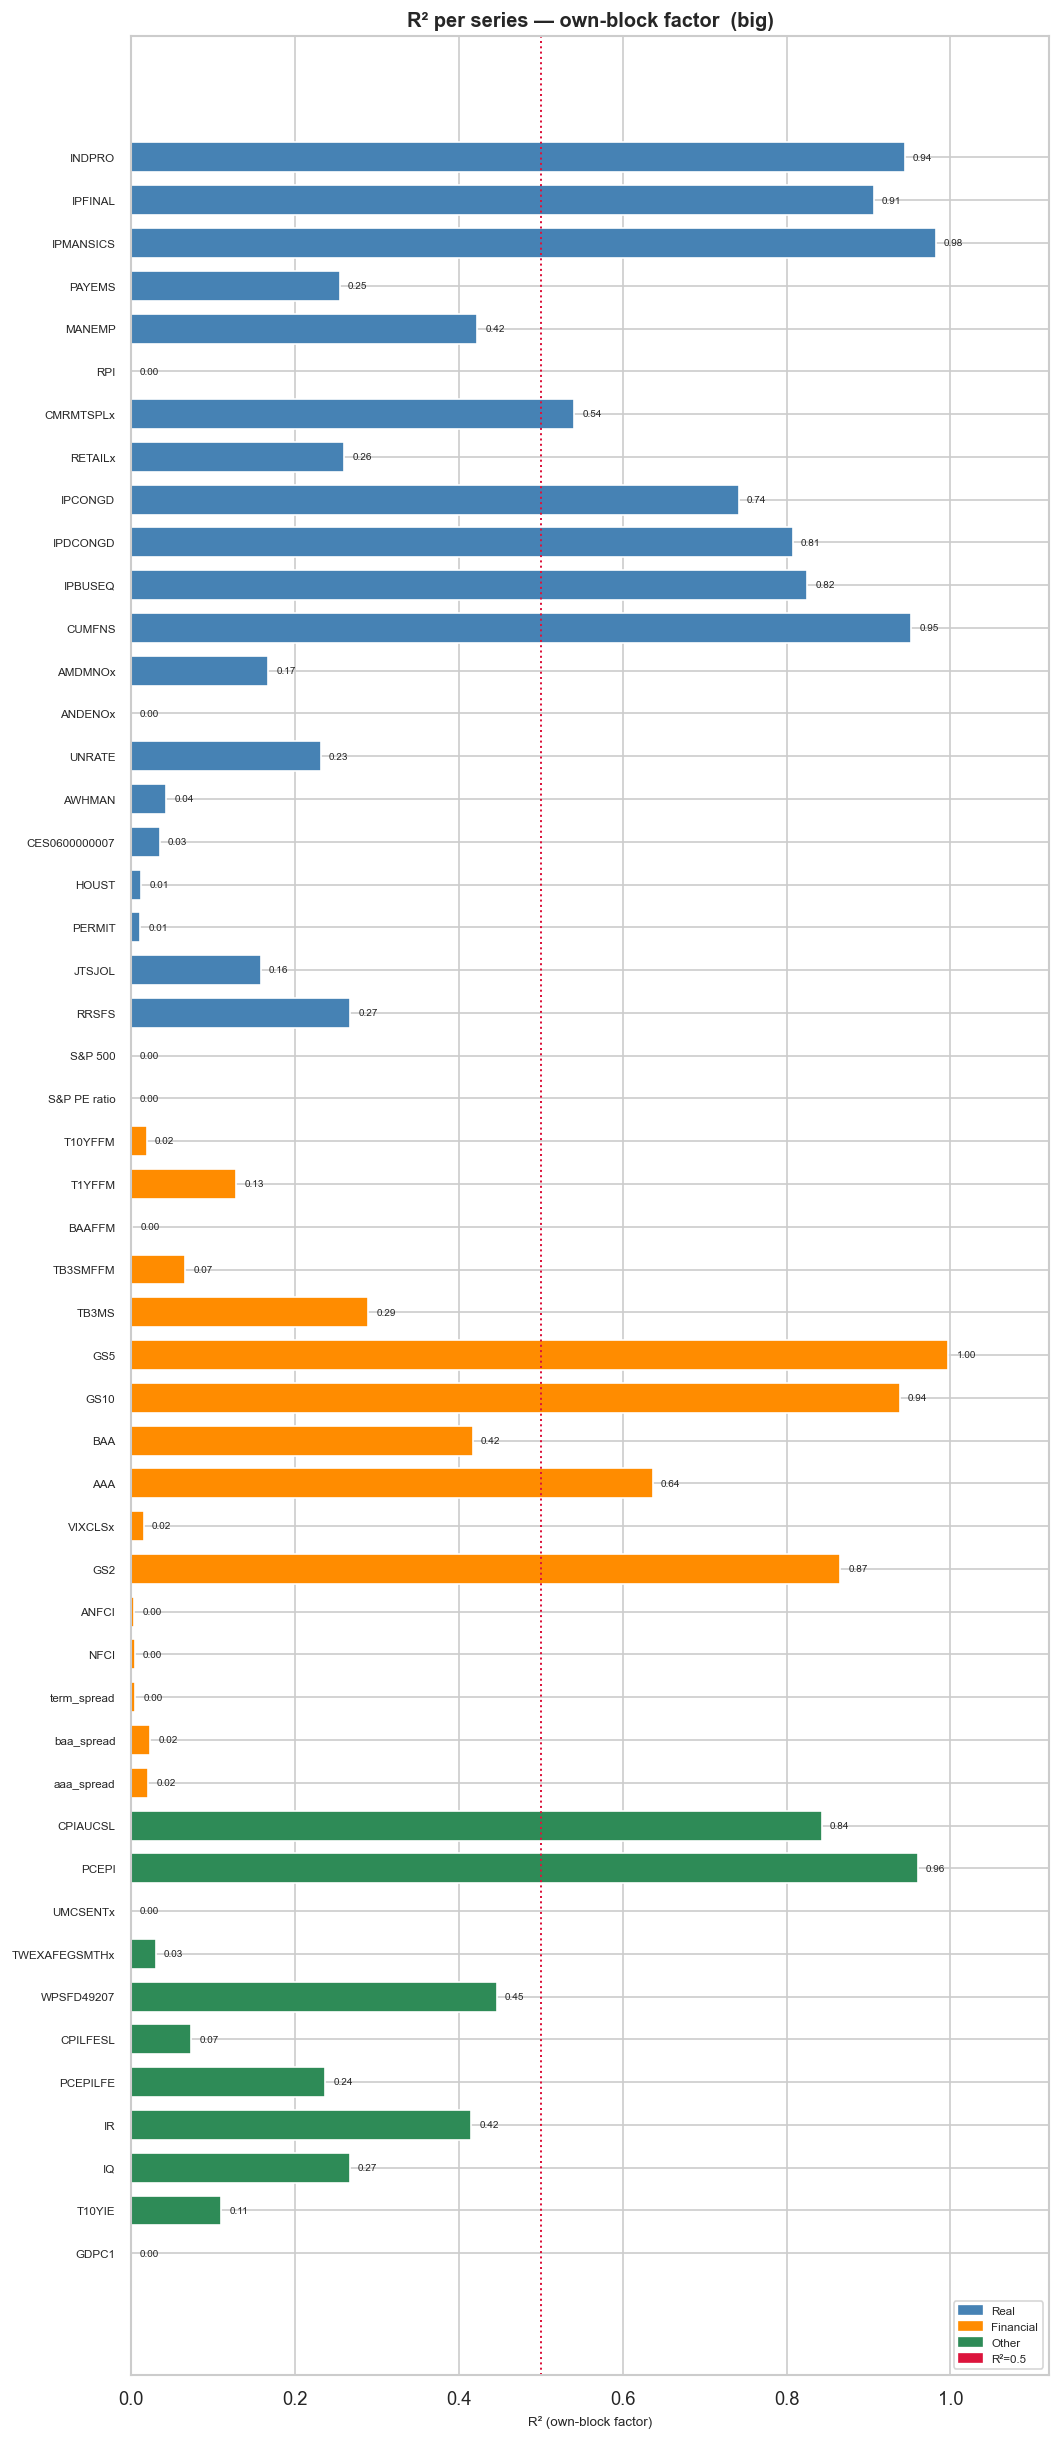

In [14]:
r2_own = {}
for i, col in enumerate(ORDERED_COLS):
    y    = df_std[col].values
    yhat = fitted[:, i]
    mask = np.isfinite(y)
    yo, yf = y[mask], yhat[mask]
    ss_res = np.sum((yo - yf) ** 2)
    ss_tot = np.sum((yo - yo.mean()) ** 2)
    r2_own[col] = float(np.clip(1 - ss_res / ss_tot, 0, 1)) if ss_tot > 0 else np.nan

r2_df = pd.DataFrame({
    "block"      : [BLOCK[c] for c in ORDERED_COLS],
    "lambda_own" : [Lambda_signed[i, BLOCKS.index(BLOCK[c])] for i, c in enumerate(ORDERED_COLS)],
    "R2_own"     : [r2_own[c] for c in ORDERED_COLS],
}, index=ORDERED_COLS)

print(f"R² summary by block ({CONFIG}):")
print(r2_df.groupby("block")["R2_own"].describe().round(3))
print()
display(r2_df.sort_values(["block", "R2_own"], ascending=[True, False]).round(4))

# ── bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, max(4, 0.38 * M + 1.5)))
colors_list = [block_colors[BLOCK[c]] for c in ORDERED_COLS]
y_pos = list(range(M))
r2_vals = [r2_own[c] for c in ORDERED_COLS]

ax.barh(y_pos, r2_vals, color=colors_list, height=0.7)
ax.set_yticks(y_pos);  ax.set_yticklabels(ORDERED_COLS, fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("R² (own-block factor)", fontsize=8)
ax.set_title(f"R² per series — own-block factor  ({CONFIG})", fontweight="bold")
ax.axvline(0.5, color="crimson", lw=1.2, linestyle=":", label="R²=0.5")
ax.set_xlim(0, 1.12)
for i, v in enumerate(r2_vals):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=6)
patches = [mpatches.Patch(color=c, label=b.capitalize()) for b, c in block_colors.items()]
patches.append(mpatches.Patch(color="crimson", label="R²=0.5"))
ax.legend(handles=patches, fontsize=7, loc="lower right")
plt.tight_layout();  plt.show()

## 2. Cross-Loading R² — Block Separation

Compute the **unconstrained OLS** R² of every series on every factor
(including off-block factors that are *excluded* from Λ by design):

$$R^2_{ij} = \text{corr}(y_i,\, f^j)^2, \quad i=1,\ldots,M,\; j \in \{R, F, N\}$$

If each factor explains primarily its own block → **diagonal dominance** in the mean-R²
block×factor matrix → the three-block restriction is empirically justified.
If off-diagonal entries rival the diagonal → the blocks are not well-separated.

Block separation matrix — mean R² (big):
                 Real factor  Financial factor  Nominal factor
Real block             0.455             0.007           0.010
Financial block        0.018             0.248           0.003
Nominal block          0.012             0.035           0.343

Mean diagonal (own-block)  : 0.349
Mean off-diagonal (cross)  : 0.014
Diagonal / off-diagonal    : 24.6x  (good separation)


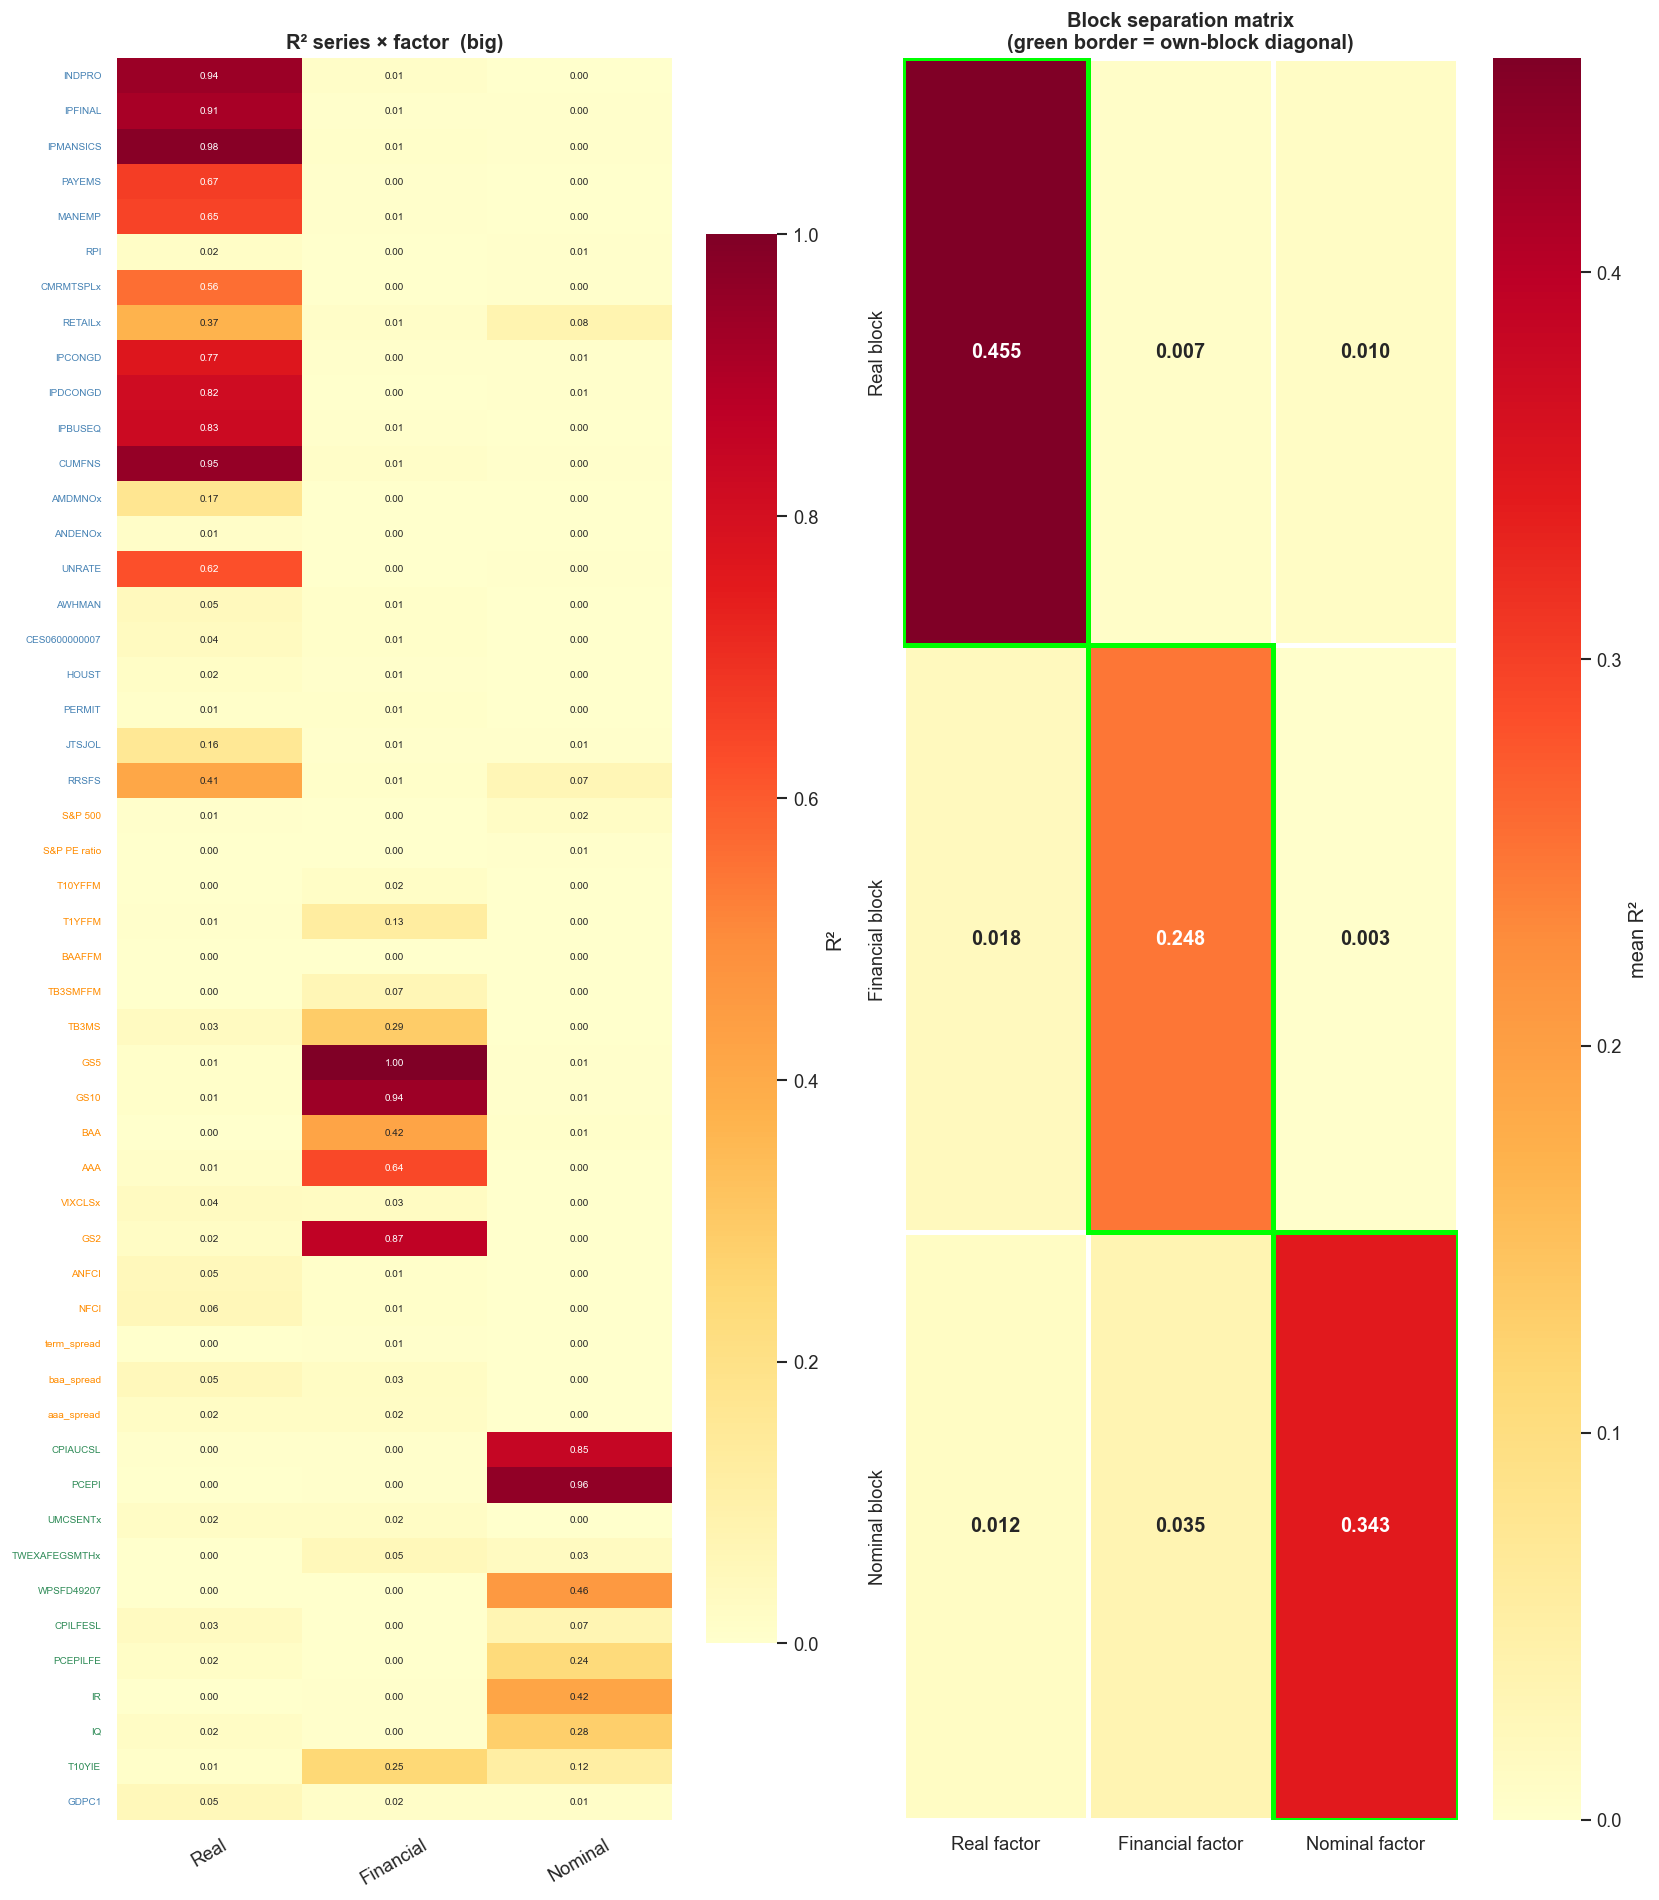

In [15]:
r2_cross = np.full((M, 3), np.nan)
for i, col in enumerate(ORDERED_COLS):
    y = df_std[col].values
    for j in range(3):
        mask = np.isfinite(y)
        yo, fj = y[mask], F[mask, j]
        if mask.sum() > 10 and np.std(yo) > 0 and np.std(fj) > 0:
            r2_cross[i, j] = float(np.corrcoef(yo, fj)[0, 1] ** 2)

r2_cdf = pd.DataFrame(
    r2_cross,
    index=ORDERED_COLS,
    columns=["R2_real", "R2_financial", "R2_nominal"],
)
r2_cdf["block"] = [BLOCK[c] for c in ORDERED_COLS]

# ── mean R² per (series-block × factor) ──────────────────────────────────────
sep = (r2_cdf.groupby("block")[["R2_real", "R2_financial", "R2_nominal"]]
       .mean().reindex(BLOCKS))
sep.index   = ["Real block", "Financial block", "Nominal block"]
sep.columns = ["Real factor", "Financial factor", "Nominal factor"]

print(f"Block separation matrix — mean R² ({CONFIG}):")
print(sep.round(3))
print()
diag_mean = np.diag(sep.values).mean()
offdiag_mean = (sep.values.sum() - np.diag(sep.values).sum()) / 6
print(f"Mean diagonal (own-block)  : {diag_mean:.3f}")
print(f"Mean off-diagonal (cross)  : {offdiag_mean:.3f}")
ratio = diag_mean / offdiag_mean if offdiag_mean > 0 else np.inf
print(f"Diagonal / off-diagonal    : {ratio:.1f}x  {'(good separation)' if ratio > 2 else '(weak separation)'}")

# ── figures ───────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(5, 0.28 * M + 2)))

plot_data = r2_cdf[["R2_real", "R2_financial", "R2_nominal"]]
plot_data.columns = ["Real factor", "Financial factor", "Nominal factor"]
sns.heatmap(plot_data, ax=ax1, cmap="YlOrRd", vmin=0, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 6},
            cbar_kws={"label": "R²", "shrink": 0.8})
for tick in ax1.get_yticklabels():
    col = tick.get_text()
    if col in BLOCK:
        tick.set_color(block_colors.get(BLOCK[col], "black"))
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=6, rotation=0)
ax1.set_xticklabels(["Real", "Financial", "Nominal"], rotation=30)
ax1.set_title(f"R² series × factor  ({CONFIG})", fontweight="bold")

sns.heatmap(sep, ax=ax2, cmap="YlOrRd", vmin=0, vmax=sep.values.max(),
            annot=True, fmt=".3f", annot_kws={"size": 12, "weight": "bold"},
            linewidths=2, linecolor="white", cbar_kws={"label": "mean R²"})
for k in range(3):
    ax2.add_patch(plt.Rectangle((k, k), 1, 1, fill=False, edgecolor="lime", lw=3))
ax2.set_title("Block separation matrix\n(green border = own-block diagonal)", fontweight="bold")

plt.tight_layout();  plt.show()

## 3. Factor Correlation

Compute the correlation matrix of the three smoothed factors.

**Important framing:** high correlations between factors are *not* a model failure
in a block factor model. In crisis episodes (2008–09, 2020) all three blocks are
hit simultaneously by a common macro shock — real activity collapses, financial
conditions tighten, and inflation reacts. The factors *should* co-move in those
periods; that is economic reality, not identification failure.

What *would* be a problem: perfect collinearity (|ρ| ≈ 1) at all times,
implying the three factors are effectively one.

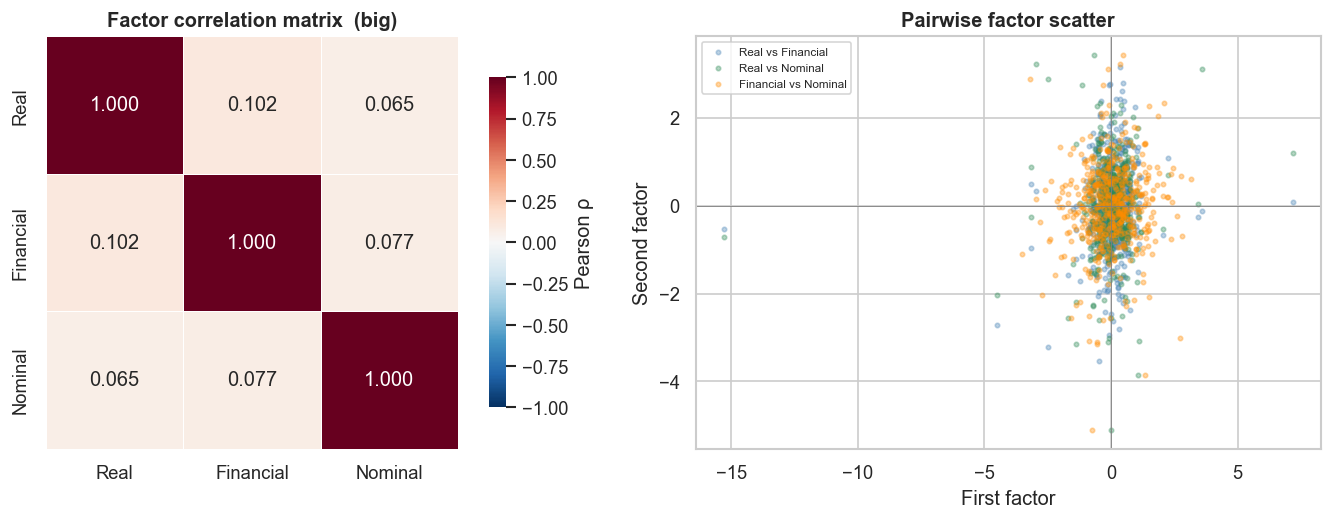


Correlation matrix: big
            Real  Financial  Nominal
Real       1.000      0.102    0.065
Financial  0.102      1.000    0.077
Nominal    0.065      0.077    1.000

Max off-diagonal |rho|: 0.102
NOTE: low correlation — factors are nearly orthogonal.


In [16]:
F_df   = pd.DataFrame(F, index=dates, columns=["Real", "Financial", "Nominal"])
corr_F = F_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.heatmap(corr_F, ax=axes[0], cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            annot=True, fmt=".3f", square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Pearson ρ"})
axes[0].set_title(f"Factor correlation matrix  ({CONFIG})", fontweight="bold")

for j1, j2, lbl, col in [
        (0, 1, "Real vs Financial", "steelblue"),
        (0, 2, "Real vs Nominal",   "seagreen"),
        (1, 2, "Financial vs Nominal", "darkorange"),
]:
    axes[1].scatter(F[:, j1], F[:, j2], alpha=0.35, s=7, color=col, label=lbl)
axes[1].axhline(0, color="gray", lw=0.5);  axes[1].axvline(0, color="gray", lw=0.5)
axes[1].set_xlabel("First factor");  axes[1].set_ylabel("Second factor")
axes[1].set_title("Pairwise factor scatter", fontweight="bold")
axes[1].legend(fontsize=7)

plt.tight_layout();  plt.show()

print("\nCorrelation matrix:", CONFIG)
print(corr_F.round(3))
max_corr = corr_F.values[np.triu(np.ones((3,3), dtype=bool), k=1)].max()
print(f"\nMax off-diagonal |rho|: {max_corr:.3f}")
if max_corr > 0.85:
    print("NOTE: very high correlation — review whether two blocks co-move structurally.")
elif max_corr > 0.5:
    print("NOTE: moderate correlation — expected in crisis periods, not a problem.")
else:
    print("NOTE: low correlation — factors are nearly orthogonal.")

## 4. PCA of the Three Factors — Dimensionality Check

Apply PCA to the (T × 3) factor matrix to test whether the three factors genuinely
span three dimensions or effectively collapse to fewer.

| Outcome | Interpretation |
|---|---|
| PC1 ≈ 95–100% | Factors are nearly **1-dimensional** — one dominant cycle drives all three |
| PC1 ≈ 50–70% | **Partial collapse** — one dominant direction but some independent variation |
| Roughly 50/30/20 or more balanced | Genuinely **3-dimensional** — blocks contribute distinct information |

This is a **diagnostic for redundancy**, not a test for choosing the number of factors
(that question is answered by the economic design).

PCA on 3 factors  (big):
  PC1:  39.0%   eigenvalue = 1.1339
  PC2:  30.7%   eigenvalue = 0.8927
  PC3:  30.2%   eigenvalue = 0.8778
  Cumulative: [ 39.040283    69.77680747 100.        ]


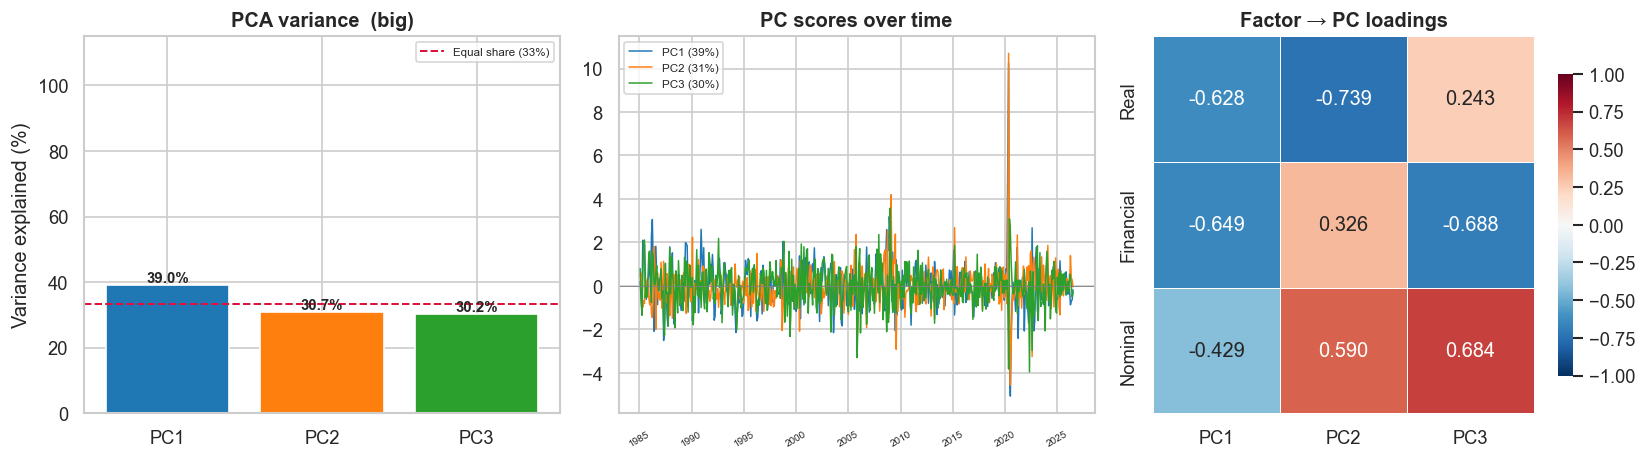

GOOD: PC1=39%, PC2=31%, PC3=30% — genuinely 3-dimensional.


In [17]:
Fc             = F - F.mean(axis=0)
evr, PC, comps_, eigvals_ = _np_pca(Fc)

print(f"PCA on 3 factors  ({CONFIG}):")
for k in range(3):
    print(f"  PC{k+1}: {evr[k]*100:5.1f}%   eigenvalue = {eigvals_[k]:.4f}")
print(f"  Cumulative: {evr.cumsum()*100}")

comp_df = pd.DataFrame(
    comps_.T,
    index=["Real", "Financial", "Nominal"],
    columns=["PC1", "PC2", "PC3"],
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# variance bar
bars = axes[0].bar(["PC1", "PC2", "PC3"], evr * 100,
                   color=["#1f77b4", "#ff7f0e", "#2ca02c"])
for bar, v in zip(bars, evr):
    axes[0].text(bar.get_x() + bar.get_width()/2, v*100 + 1,
                 f"{v*100:.1f}%", ha="center", fontsize=9, fontweight="bold")
axes[0].axhline(100/3, color="crimson", lw=1.2, linestyle="--", label="Equal share (33%)")
axes[0].set_ylim(0, 115);  axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title(f"PCA variance  ({CONFIG})", fontweight="bold")
axes[0].legend(fontsize=7)

# PC scores
for k, col in enumerate(["#1f77b4", "#ff7f0e", "#2ca02c"]):
    axes[1].plot(dates, PC[:, k], color=col, lw=0.9, label=f"PC{k+1} ({evr[k]*100:.0f}%)")
axes[1].axhline(0, color="gray", lw=0.5)
axes[1].set_title("PC scores over time", fontweight="bold")
axes[1].tick_params(axis="x", labelsize=6, rotation=30)
axes[1].legend(fontsize=7)

# loadings heatmap
sns.heatmap(comp_df, ax=axes[2], cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".3f", linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[2].set_title("Factor → PC loadings", fontweight="bold")

plt.tight_layout();  plt.show()

if evr[0] > 0.80:
    print(f"WARNING: PC1={evr[0]*100:.0f}% — factors near 1-dimensional. Strong common component.")
elif evr[0] > 0.55:
    print(f"MODERATE: PC1={evr[0]*100:.0f}% — one dominant direction but 3D retained.")
else:
    print(f"GOOD: PC1={evr[0]*100:.0f}%, PC2={evr[1]*100:.0f}%, PC3={evr[2]*100:.0f}% — genuinely 3-dimensional.")

## 5. VAR(1) Factor Dynamics — Matrix A

The factor VAR(1) is $f_t = A f_{t-1} + u_t$.

- **Diagonal of A**: own-persistence of each block factor.
- **Off-diagonal of A**: cross-block predictability (one factor helps predict another).
- **Eigenvalues of A**: spectral radius < 1 → system is stable (stationary).
  The eigenvector of the *largest* eigenvalue reveals which combination of factors
  is most persistent ("the business cycle direction").

VAR(1) transition matrix A  (big):
               Real_{t-1}  Financial_{t-1}  Nominal_{t-1}
→ Real_t           0.0699          -0.0881        -0.0099
→ Financial_t     -0.0701           0.3419         0.1355
→ Nominal_t        0.1266           0.0373        -0.2310

Eigenvalues : [0.3628 0.2441 0.0621]
Spectral radius: 0.3628  (STABLE)

Most persistent eigenvalue  : 0.3628  (|λ|=0.3628)
Dominant factor             : Financial
Eigenvector weights         : Real=0.231  Fin=0.768  Nom=0.001


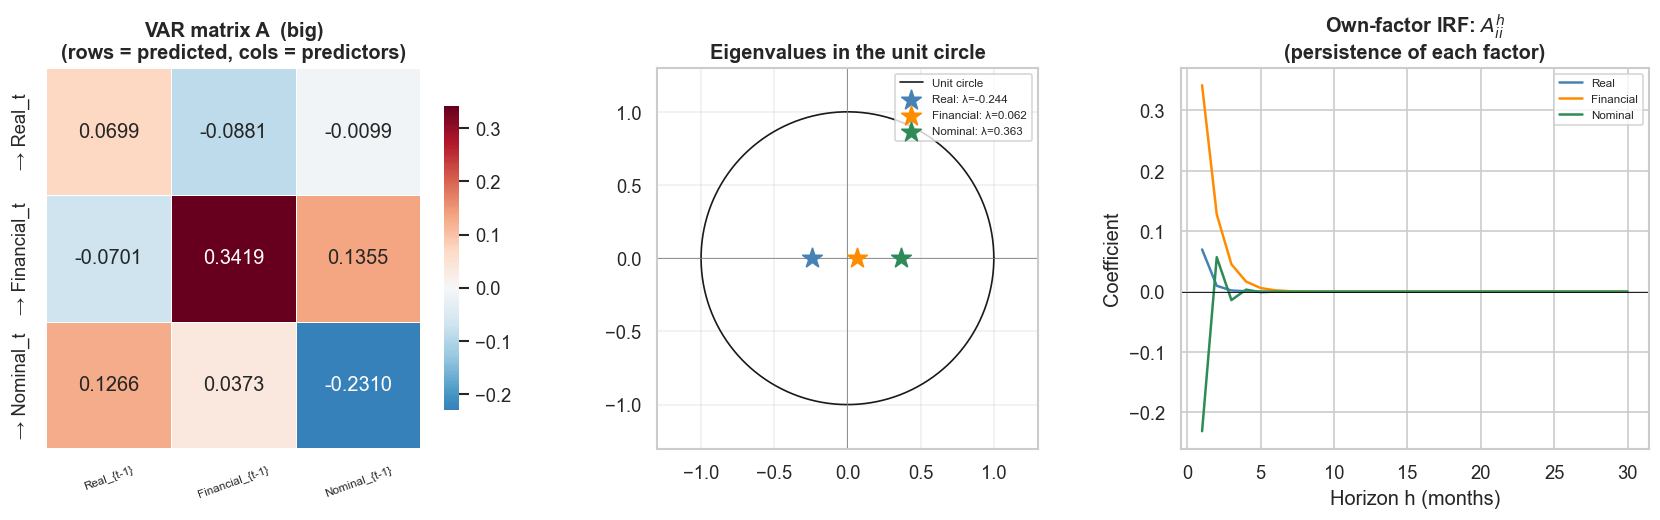

In [18]:
eigvals_A, eigvecs_A = np.linalg.eig(A_mat)
rho_A = np.max(np.abs(eigvals_A))

print(f"VAR(1) transition matrix A  ({CONFIG}):")
A_df = pd.DataFrame(
    A_mat,
    index  =["→ Real_t",  "→ Financial_t",  "→ Nominal_t"],
    columns=["Real_{t-1}", "Financial_{t-1}", "Nominal_{t-1}"],
)
print(A_df.round(4).to_string())
print()
print(f"Eigenvalues : {np.sort(np.abs(eigvals_A))[::-1].round(4)}")
print(f"Spectral radius: {rho_A:.4f}  ({'STABLE' if rho_A < 1 else '*** UNSTABLE ***'})")
print()

idx_max = np.argmax(np.abs(eigvals_A))
ev_dom  = eigvals_A[idx_max]
ec_dom  = np.abs(eigvecs_A[:, idx_max]) / np.abs(eigvecs_A[:, idx_max]).sum()
dom_fac = ["Real", "Financial", "Nominal"][np.argmax(ec_dom)]
print(f"Most persistent eigenvalue  : {ev_dom.real:.4f}  (|λ|={abs(ev_dom):.4f})")
print(f"Dominant factor             : {dom_fac}")
print(f"Eigenvector weights         : Real={ec_dom[0]:.3f}  Fin={ec_dom[1]:.3f}  Nom={ec_dom[2]:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# A heatmap
sns.heatmap(A_df, ax=axes[0], cmap="RdBu_r", center=0,
            annot=True, fmt=".4f", linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[0].set_title(f"VAR matrix A  ({CONFIG})\n(rows = predicted, cols = predictors)", fontweight="bold")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, fontsize=7)

# eigenvalues in unit circle
theta_circ = np.linspace(0, 2*np.pi, 300)
axes[1].plot(np.cos(theta_circ), np.sin(theta_circ), "k-", lw=1, label="Unit circle")
axes[1].axhline(0, color="gray", lw=0.5);  axes[1].axvline(0, color="gray", lw=0.5)
for j, (ev, col, lbl) in enumerate(zip(eigvals_A, factor_colors, ["Real","Financial","Nominal"])):
    axes[1].scatter(ev.real, ev.imag, s=150, zorder=5, color=col,
                    label=f"{lbl}: λ={ev.real:.3f}", marker="*")
axes[1].set_xlim(-1.3, 1.3);  axes[1].set_ylim(-1.3, 1.3)
axes[1].set_aspect("equal");  axes[1].legend(fontsize=7, loc="upper right")
axes[1].set_title("Eigenvalues in the unit circle", fontweight="bold")
axes[1].grid(True, alpha=0.3)

# diagonal IRFs (f_i,t+h response to own shock)
h_max = 30
irf_diag = np.zeros((h_max, 3))
A_h = np.eye(3)
for h in range(h_max):
    A_h = A_h @ A_mat
    irf_diag[h] = np.diag(A_h)

for j, (col, lbl) in enumerate(zip(factor_colors, ["Real", "Financial", "Nominal"])):
    axes[2].plot(range(1, h_max+1), irf_diag[:, j], color=col, lw=1.5, label=lbl)
axes[2].axhline(0, color="black", lw=0.5)
axes[2].set_xlabel("Horizon h (months)");  axes[2].set_ylabel("Coefficient")
axes[2].set_title("Own-factor IRF: $A^h_{ii}$\n(persistence of each factor)", fontweight="bold")
axes[2].legend(fontsize=7)

plt.tight_layout();  plt.show()

## 6. Variance Decomposition

For each series $y_i$, decompose the variance into:

$$\text{Var}(y_i) = \underbrace{\text{Var}(\hat{y}_i)}_{\text{factor}} + \underbrace{\text{Var}(\varepsilon_i)}_{\text{idiosyncratic}}$$

where $\hat{y}_i = \lambda_i f^{b(i)}$ is the factor-fitted value.
The **factor share** $= \text{Var}(\hat{y}_i) / \text{Var}(y_i)$ measures how much
of the series' variance is explained by the single block factor.

Variance decomposition by block  (big):
           factor_share  idio_share
block                              
financial         0.248       0.755
other             0.281       0.662
real              0.364       0.627

Overall mean factor share : 30.6%
Overall mean idio  share  : 68.0%


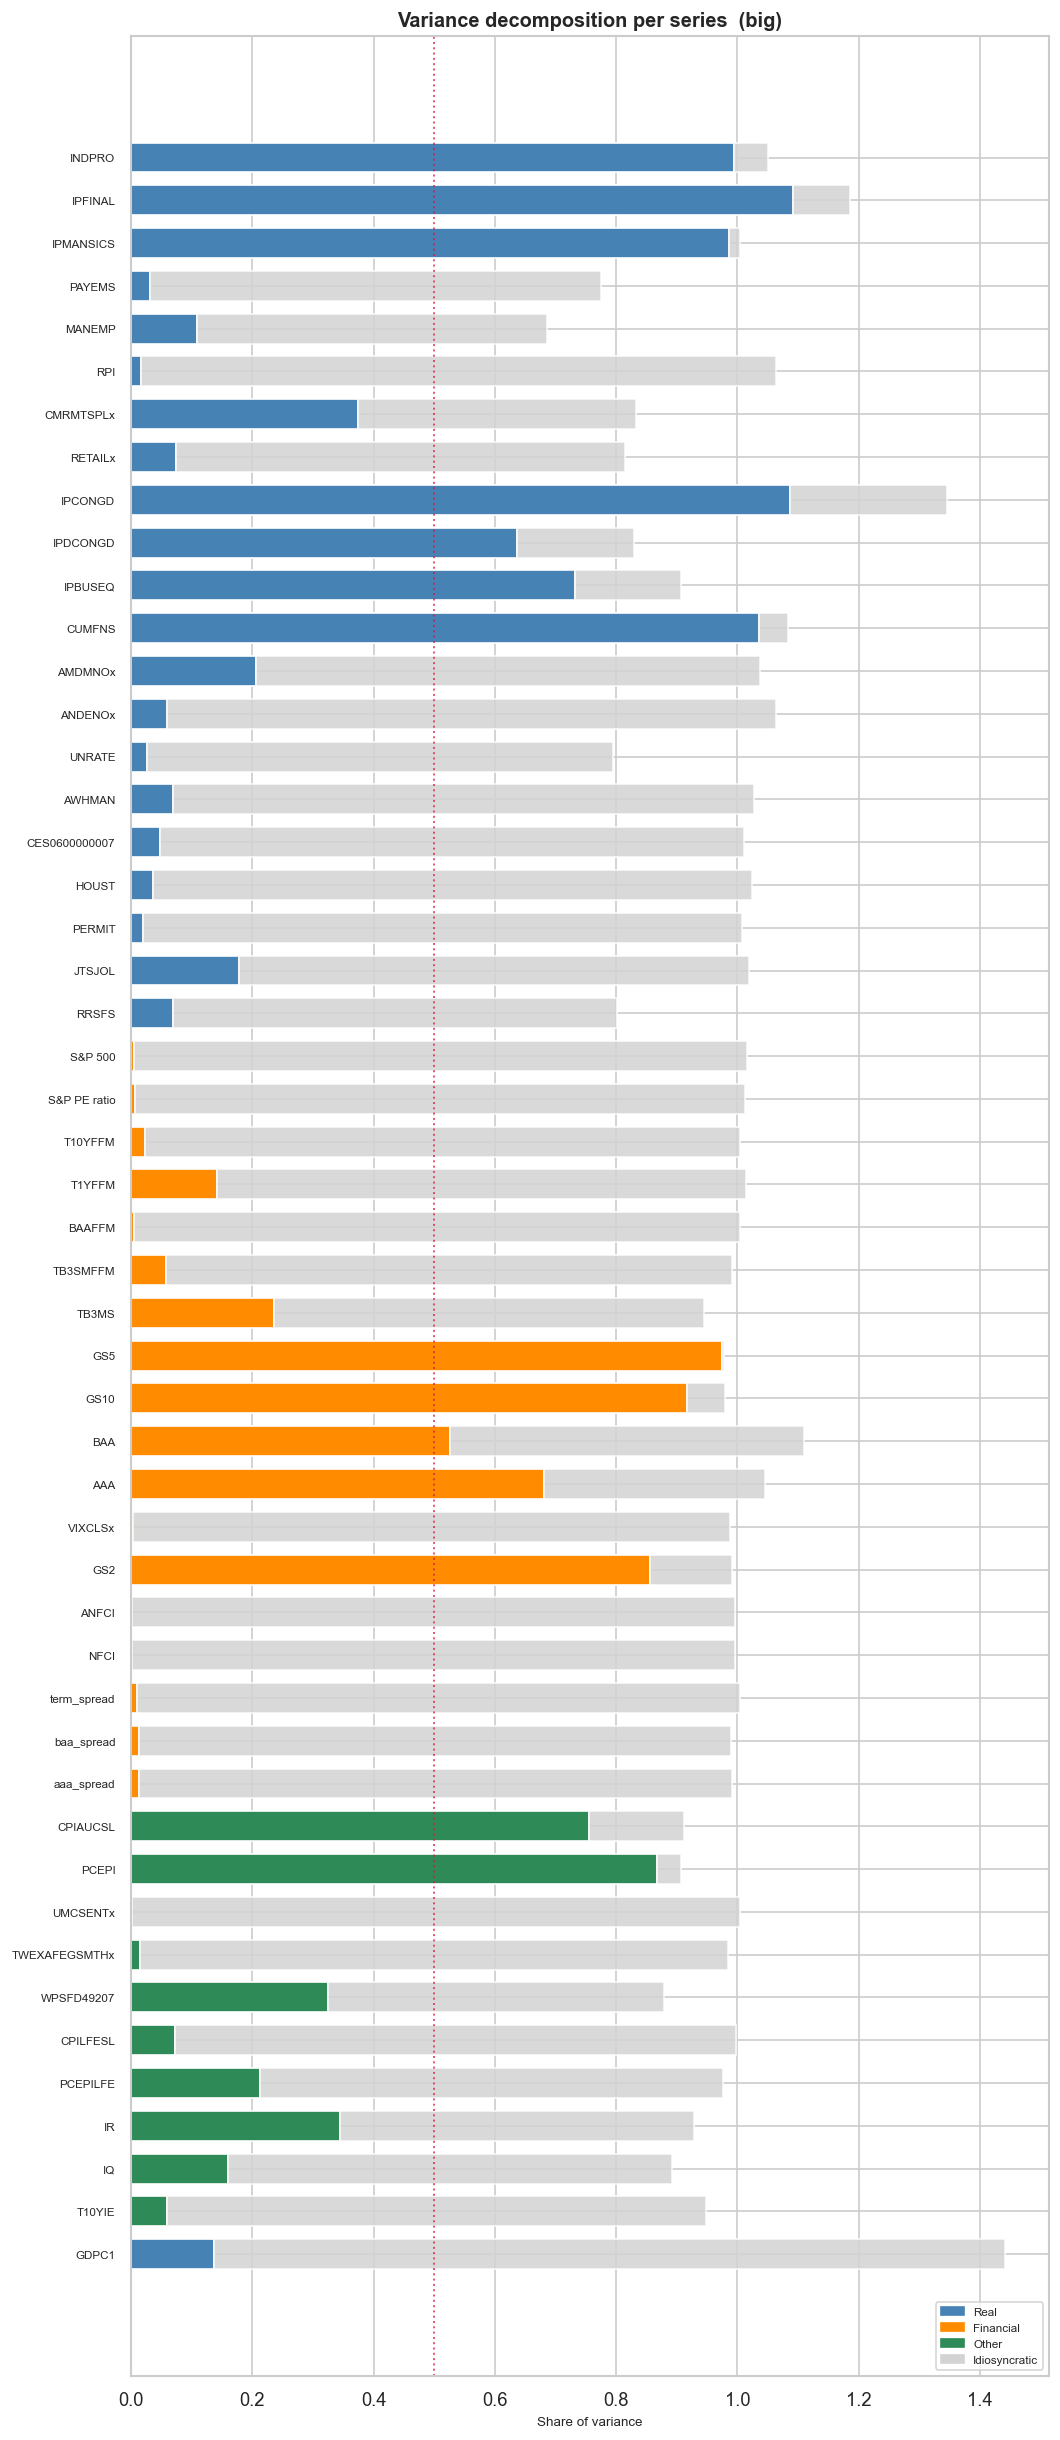

In [19]:
factor_share = np.full(M, np.nan)
idio_share   = np.full(M, np.nan)

for i, col in enumerate(ORDERED_COLS):
    y    = df_std[col].values
    yhat = fitted[:, i]
    mask = np.isfinite(y)
    yo, yf = y[mask], yhat[mask]
    eps    = yo - yf
    var_y  = np.var(yo)
    if var_y > 0:
        factor_share[i] = np.var(yf) / var_y
        idio_share[i]   = np.var(eps) / var_y

vd_df = pd.DataFrame({
    "block"        : [BLOCK[c] for c in ORDERED_COLS],
    "factor_share" : factor_share,
    "idio_share"   : idio_share,
}, index=ORDERED_COLS)

print(f"Variance decomposition by block  ({CONFIG}):")
print(vd_df.groupby("block")[["factor_share", "idio_share"]].mean().round(3))
total_fshare = np.nanmean(factor_share)
print(f"\nOverall mean factor share : {total_fshare*100:.1f}%")
print(f"Overall mean idio  share  : {np.nanmean(idio_share)*100:.1f}%")

fig, ax = plt.subplots(figsize=(9, max(4, 0.38 * M + 1.5)))
y_pos = list(range(M))
colors_list = [block_colors[BLOCK[c]] for c in ORDERED_COLS]

ax.barh(y_pos, factor_share, color=colors_list, height=0.7, label="Factor")
ax.barh(y_pos, idio_share, left=factor_share,
        color="lightgray", height=0.7, alpha=0.85, label="Idiosyncratic")
ax.set_yticks(y_pos);  ax.set_yticklabels(ORDERED_COLS, fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("Share of variance", fontsize=8)
ax.set_title(f"Variance decomposition per series  ({CONFIG})", fontweight="bold")
ax.axvline(0.5, color="crimson", lw=1.2, linestyle=":", alpha=0.7)
patches = [mpatches.Patch(color=c, label=b.capitalize()) for b, c in block_colors.items()]
patches.append(mpatches.Patch(color="lightgray", label="Idiosyncratic"))
ax.legend(handles=patches, fontsize=7, loc="lower right")
plt.tight_layout();  plt.show()

## 7. Idiosyncratic Residual Correlation

After subtracting the factor component, the idiosyncratic residuals
$\varepsilon_{it} = y_{it} - \hat{y}_{it}$ should be *approximately* uncorrelated
across series (DFM identifying assumption: all cross-sectional dependence
is captured by the common factors).

**What to look for:**
- **Within-block residual correlations** (block diagonal): these reflect
  within-block heterogeneity not captured by the single block factor.
- **Cross-block residual correlations** (off-block): if large, there is
  a latent factor that cuts across blocks — a candidate for model extension.

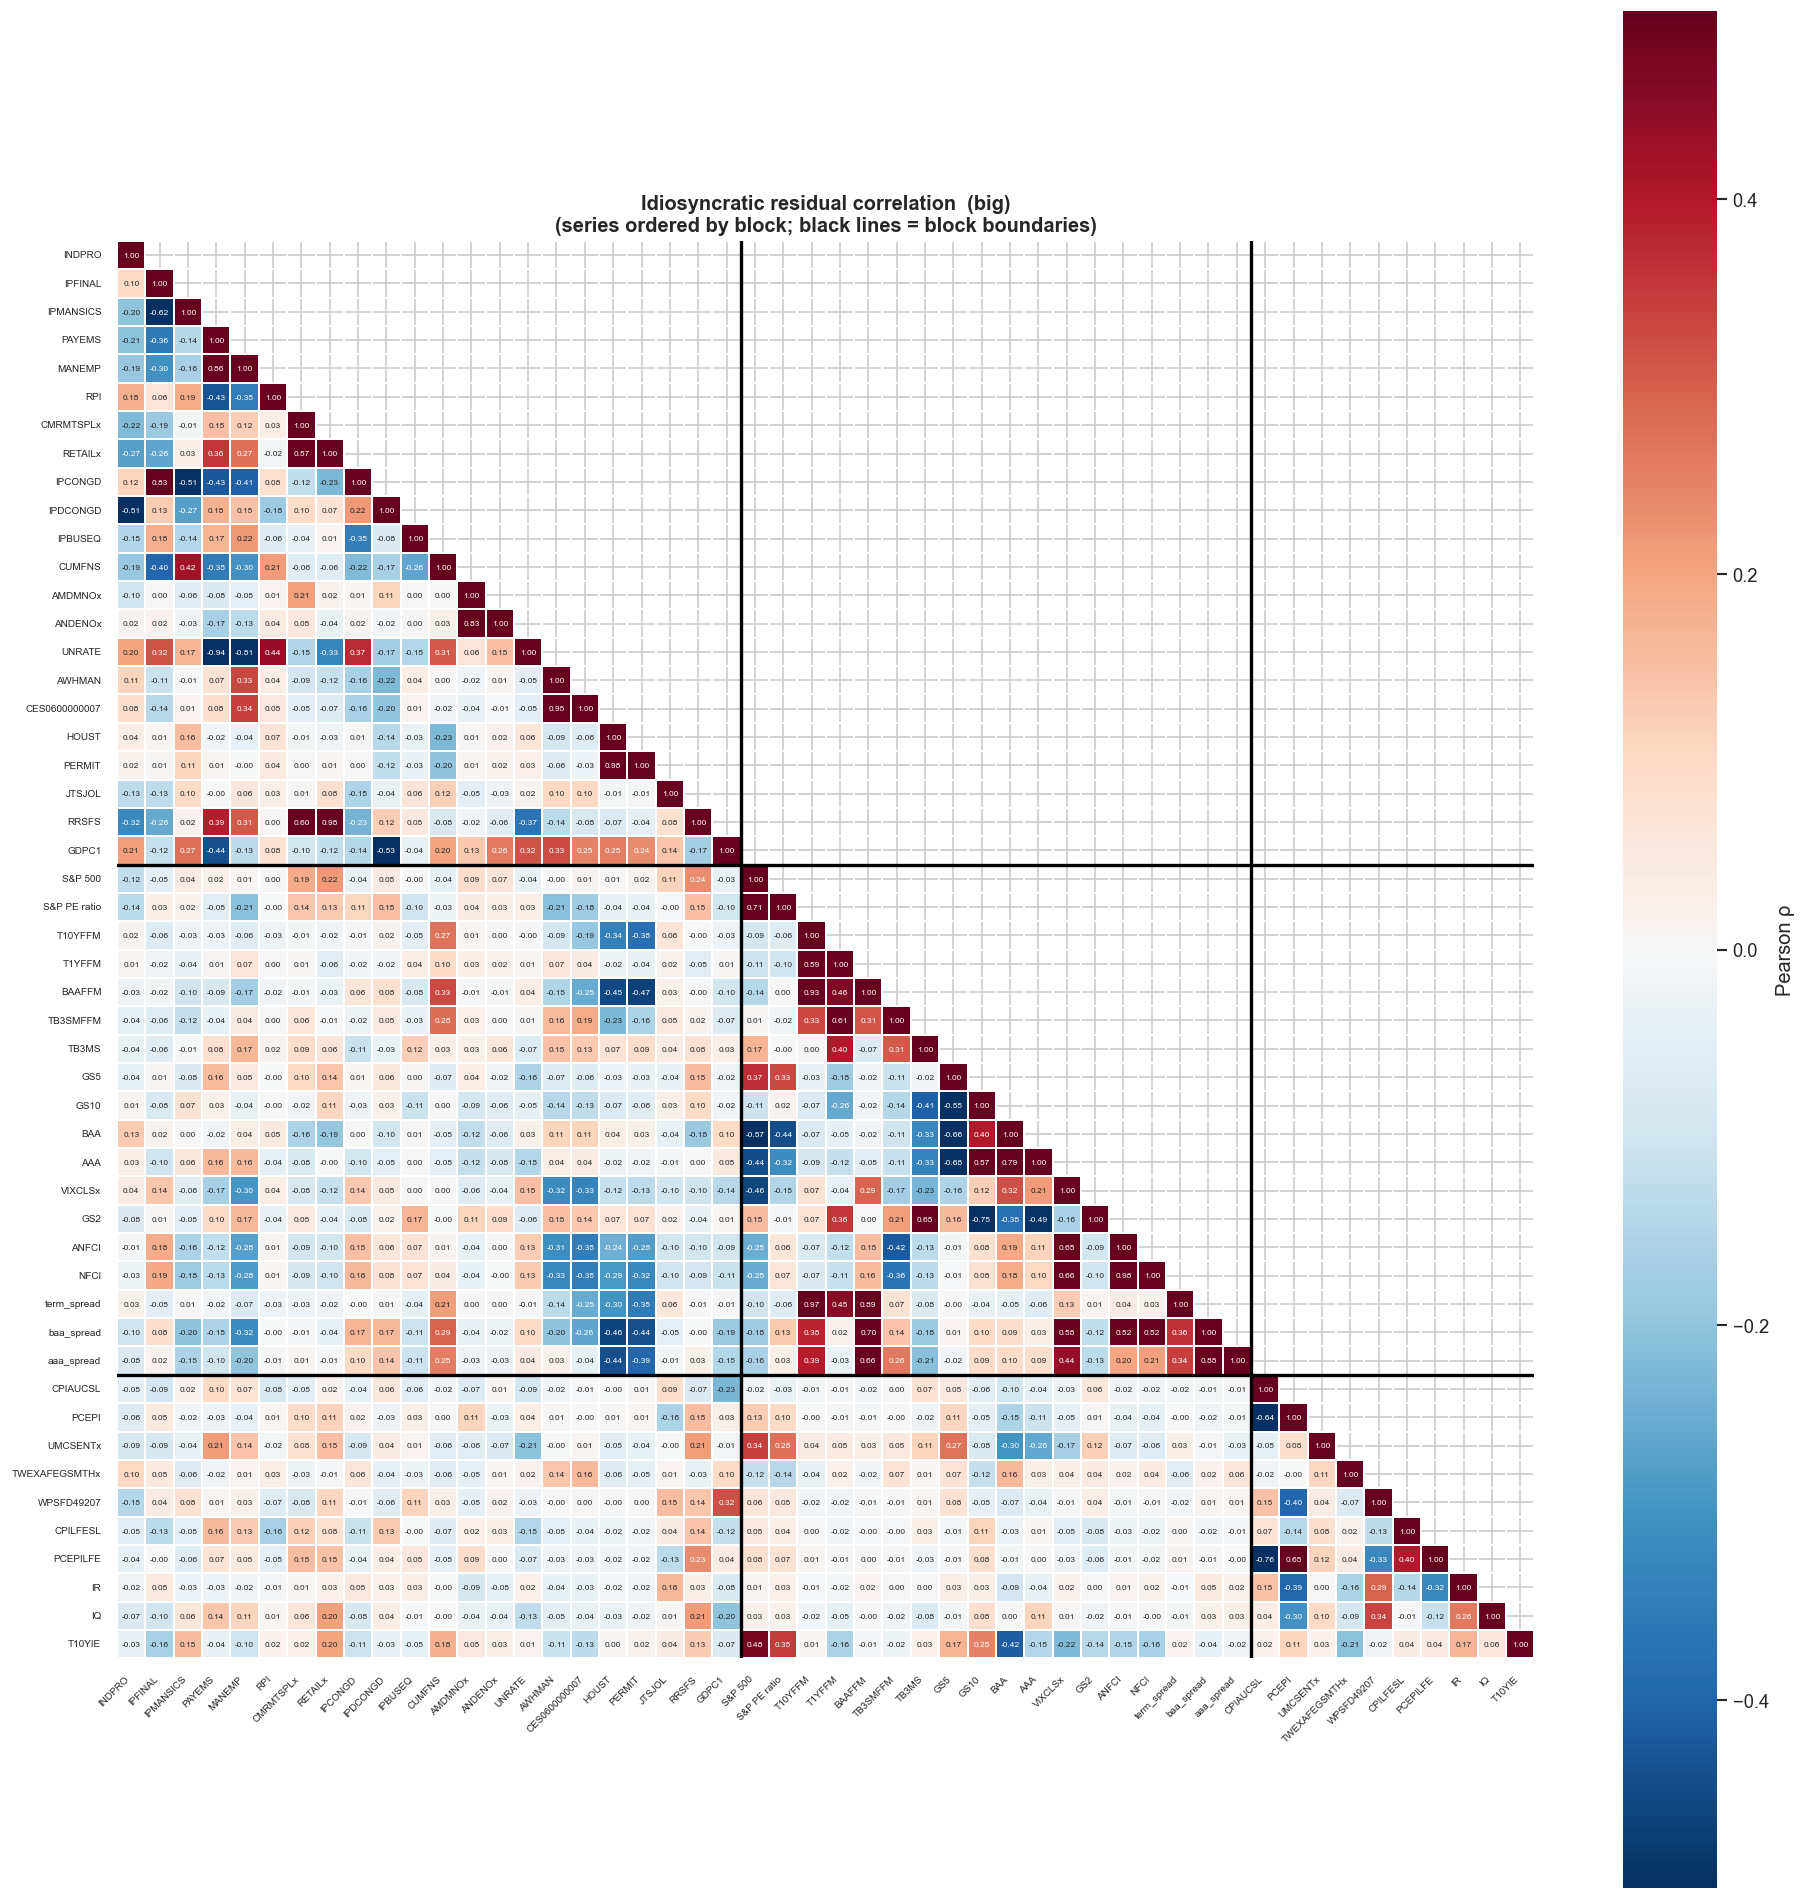

Residual correlation stats (big):
  Max  |ρ|  = 0.983
  Mean |ρ|  = 0.116
  Frac |ρ|>0.3 = 10.0%
  → Residual correlations are small: block structure captures most dependence.


In [20]:
resid_mat = np.full((T, M), np.nan)
for i, col in enumerate(ORDERED_COLS):
    y = df_std[col].values
    resid_mat[:, i] = y - fitted[:, i]

resid_df   = pd.DataFrame(resid_mat, columns=ORDERED_COLS)
corr_resid = resid_df.corr()

# reorder by block
col_order = sum([cols_by_block[b] for b in BLOCKS], [])
col_order  = [c for c in col_order if c in corr_resid.columns]
cr_ord     = corr_resid.loc[col_order, col_order]

fig, ax = plt.subplots(figsize=(max(7, 0.28*M+2), max(6, 0.28*M+2)))
mask_tri = np.triu(np.ones_like(cr_ord, dtype=bool), k=1)
sns.heatmap(cr_ord, ax=ax, cmap="RdBu_r", vmin=-0.5, vmax=0.5, center=0,
            mask=mask_tri,
            annot=True, fmt=".2f", annot_kws={"size": 5},
            linewidths=0.15, square=True,
            xticklabels=True, yticklabels=True,
            cbar_kws={"label": "Pearson ρ"})
ax.set_xticklabels(ax.get_xticklabels(), fontsize=6, rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=6)

# block separators
cum = 0
for b in BLOCKS[:-1]:
    cum += len(cols_by_block[b])
    ax.axhline(cum, color="black", lw=2)
    ax.axvline(cum, color="black", lw=2)

ax.set_title(
    f"Idiosyncratic residual correlation  ({CONFIG})\n"
    "(series ordered by block; black lines = block boundaries)",
    fontweight="bold",
)
plt.tight_layout();  plt.show()

# summary statistics
upper = cr_ord.values[np.tril(np.ones_like(cr_ord.values, dtype=bool), k=-1)]
upper = upper[~np.isnan(upper)]
print(f"Residual correlation stats ({CONFIG}):")
print(f"  Max  |ρ|  = {np.max(np.abs(upper)):.3f}")
print(f"  Mean |ρ|  = {np.mean(np.abs(upper)):.3f}")
print(f"  Frac |ρ|>0.3 = {np.mean(np.abs(upper)>0.3)*100:.1f}%")
if np.mean(np.abs(upper) > 0.3) > 0.15:
    print("  → Substantial residual correlation: consider a global common factor.")
else:
    print("  → Residual correlations are small: block structure captures most dependence.")

## 8. Small vs Big Comparison

Reload both configs independently and compare key specification diagnostics.
This section is **self-contained** and runs regardless of the `CONFIG` switch above.

In [21]:
def _load_spec(cfg_name, project_root):
    """Load all arrays needed for specification diagnostics for one config."""
    from data_loader import load_config as _lc
    import numpy as np, pandas as pd

    cfg  = _lc(cfg_name)
    oc   = cfg["ORDERED_COLS"];  bl = cfg["BLOCK"];  M_ = len(oc)
    BLKS = ["real", "financial", "other"]

    df_r = pd.read_csv(
        os.path.join(project_root, "data", "processed", f"dataset_{cfg_name}.csv"),
        index_col=0, parse_dates=True)
    df_s = (df_r - df_r.mean()) / df_r.std()

    npz  = np.load(
        os.path.join(project_root, "data", "processed", cfg_name, "fit_dfm_result.npz"),
        allow_pickle=True)
    T_   = int(npz["T"])
    sf   = np.array([int(npz["sign_flip__real"]),
                     int(npz["sign_flip__financial"]),
                     int(npz["sign_flip__other"])], dtype=float)
    F_   = npz["f_smooth"][:, :3] * sf
    fit_ = npz["fitted_values_raw"]
    A_   = npz["theta__A"]

    # R² own-block
    r2_own_ = []
    for i, col in enumerate(oc):
        y  = df_s[col].values; yh = fit_[:, i]
        mask = np.isfinite(y); yo, yf = y[mask], yh[mask]
        ss_r = np.sum((yo-yf)**2); ss_t = np.sum((yo-yo.mean())**2)
        r2_own_.append(float(np.clip(1-ss_r/ss_t, 0, 1)) if ss_t > 0 else np.nan)

    # cross-loading R²
    r2c_ = np.full((M_, 3), np.nan)
    for i, col in enumerate(oc):
        y = df_s[col].values
        for j in range(3):
            mask = np.isfinite(y); yo, fj = y[mask], F_[mask, j]
            if mask.sum() > 10 and np.std(yo) > 0 and np.std(fj) > 0:
                r2c_[i, j] = float(np.corrcoef(yo, fj)[0, 1]**2)

    sep_ = pd.DataFrame(
        [[np.mean([r2c_[i,j] for i,c in enumerate(oc) if bl[c]==b]) for j in range(3)]
         for b in BLKS],
        index=["Real bl.", "Fin. bl.", "Nom. bl."],
        columns=["Real f.", "Fin. f.", "Nom. f."],
    )

    Fc_  = F_ - F_.mean(0)
    evr_, _scores, _comps, _eigs = _np_pca(Fc_)
    corr_= pd.DataFrame(F_, columns=["Real","Fin","Nom"]).corr()
    cols_bb = {b: [c for c in oc if bl[c]==b] for b in BLKS}

    # residual correlations
    rm = np.full((T_, M_), np.nan)
    for i, col in enumerate(oc):
        rm[:, i] = df_s[col].values - fit_[:, i]
    rdf = pd.DataFrame(rm, columns=oc)
    co  = [c for b in BLKS for c in cols_bb[b] if c in rdf.columns]
    cr_ = rdf.corr().loc[co, co]
    up_ = cr_.values[np.tril(np.ones_like(cr_.values, dtype=bool), k=-1)]
    up_ = up_[~np.isnan(up_)]

    return dict(
        cfg=cfg_name, M=M_, T=T_, oc=oc, bl=bl, blks=BLKS, cols_bb=cols_bb,
        F=F_, A=A_, r2_own=r2_own_, sep=sep_, evr=evr_,
        corr=corr_, resid_corr=cr_, resid_up=up_,
        nu_u=float(npz["theta__nu_u"]), nu_eps=float(npz["theta__nu_eps"]),
        converged=bool(npz["converged"]), n_iter=int(npz["n_iter"]),
    )

print("Loading small and big results...")
D = {n: _load_spec(n, project_root) for n in ["small", "big"]}
print("Done.")

Loading small and big results...
Done.


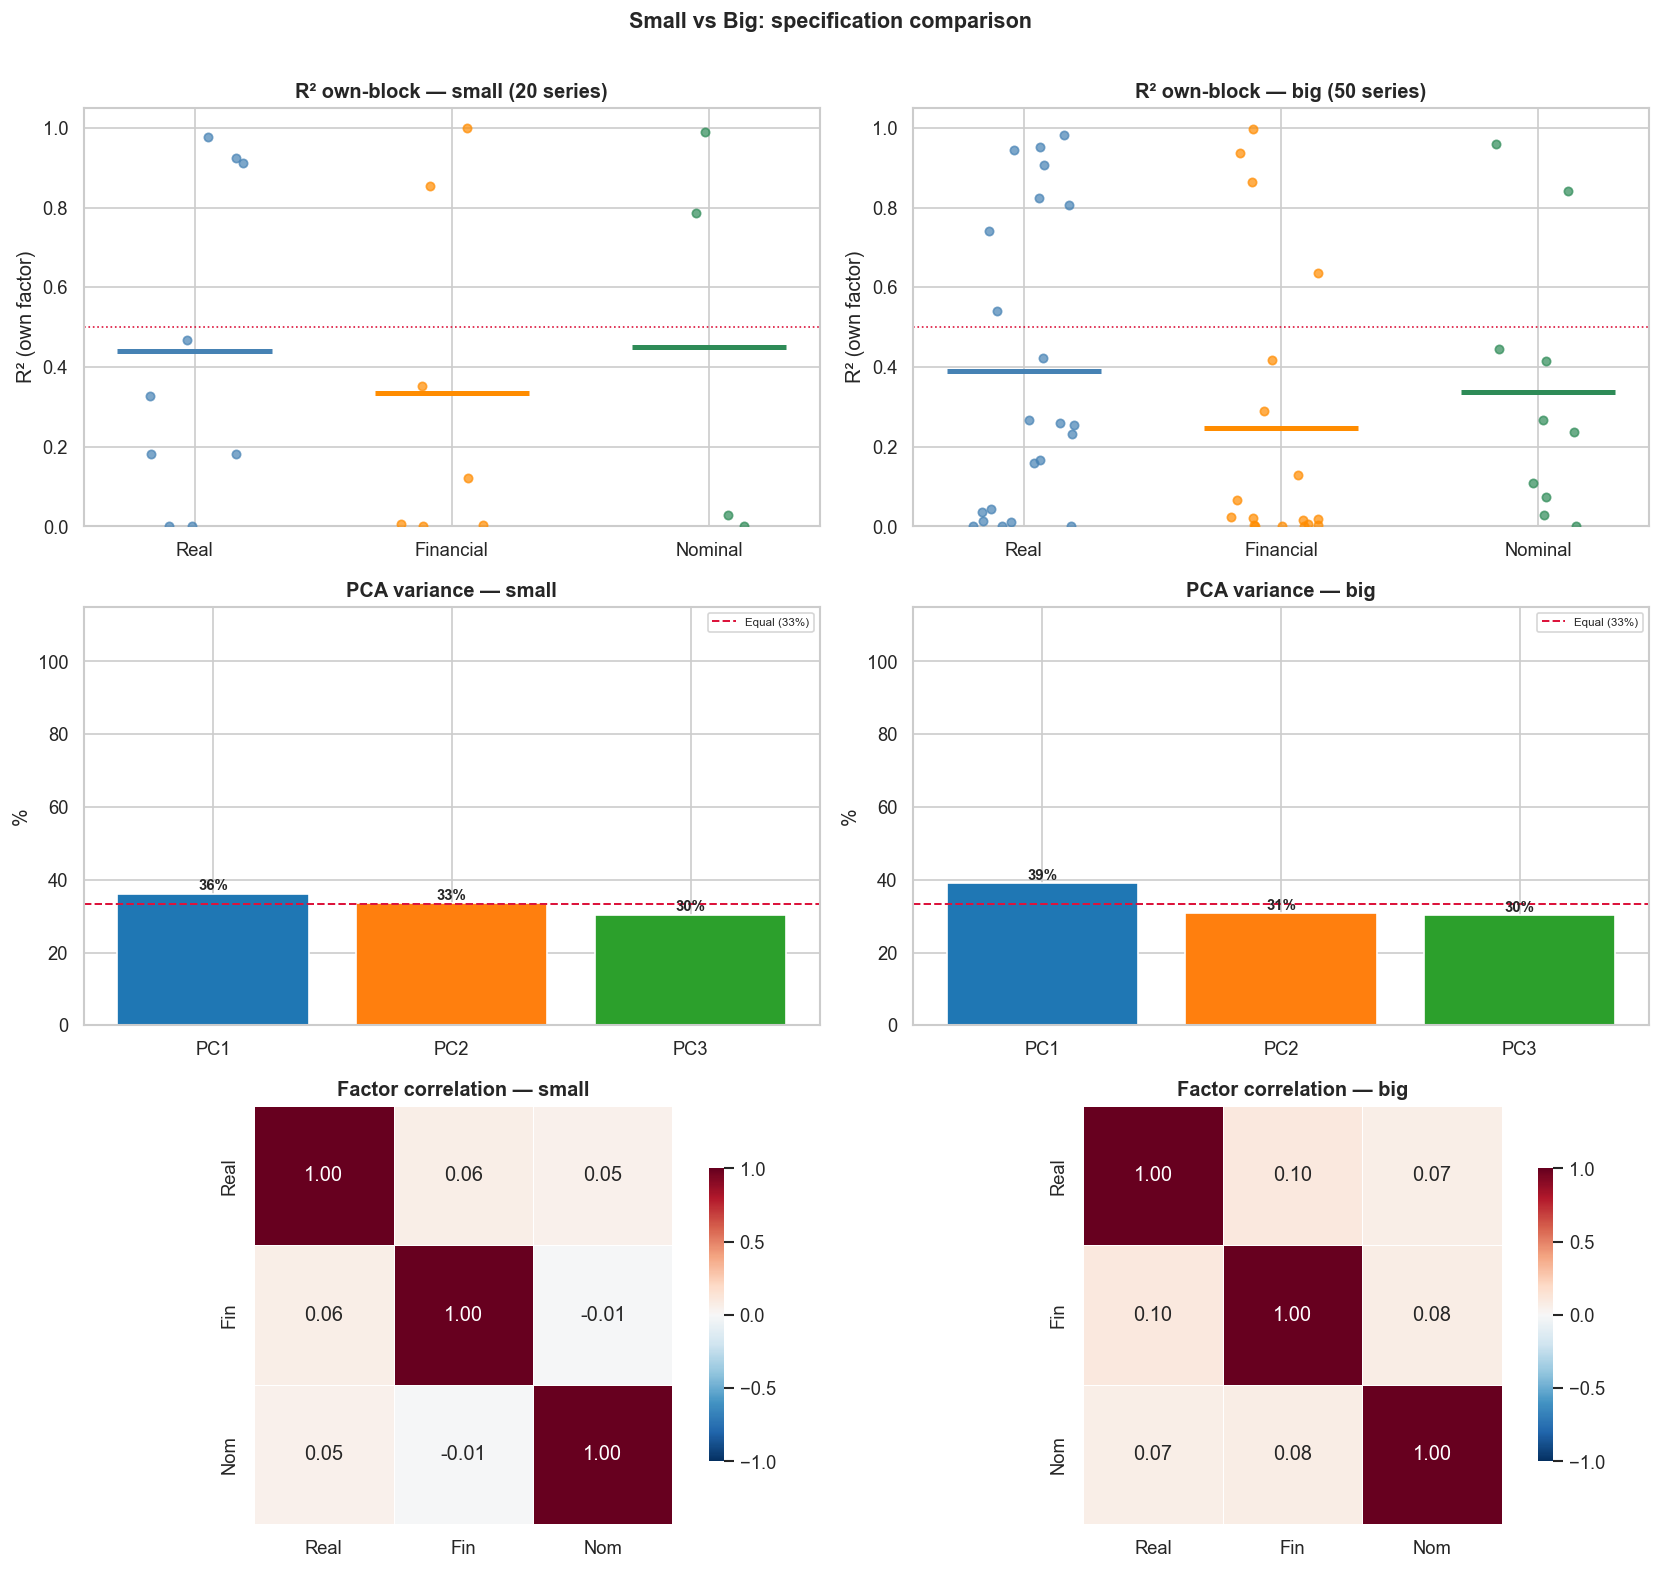


SPECIFICATION SUMMARY

──────────────────────────────  SMALL  (20 series, T=497)
  Converged   : True  (110 iter)
  nu_u/nu_eps : 4.08 / 4.40
  R² mean     : real=0.441  fin=0.334  nom=0.451
  PCA var     : PC1=36%  PC2=33%  PC3=30%
  Block sep   : diag=0.443  off-diag=0.007  ratio=67.2x
  Resid corr  : mean|ρ|=0.136  max|ρ|=0.883
  Spectral ρ(A): 0.9782

──────────────────────────────  BIG  (50 series, T=498)
  Converged   : True  (32 iter)
  nu_u/nu_eps : 4.52 / 7.01
  R² mean     : real=0.389  fin=0.246  nom=0.338
  PCA var     : PC1=39%  PC2=31%  PC3=30%
  Block sep   : diag=0.349  off-diag=0.014  ratio=24.6x
  Resid corr  : mean|ρ|=0.116  max|ρ|=0.983
  Spectral ρ(A): 0.3628


In [22]:
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
bcolors = {"real": "steelblue", "financial": "darkorange", "other": "seagreen"}

for col_i, cfg_name in enumerate(["small", "big"]):
    d = D[cfg_name]

    # ── row 0: R² by block (dot + mean bar) ──────────────────────────────────
    ax = axes[0, col_i]
    x_map = {"real": 0, "financial": 1, "other": 2}
    for i, c in enumerate(d["oc"]):
        b  = d["bl"][c]
        x  = x_map[b] + np.random.uniform(-0.2, 0.2)
        ax.scatter(x, d["r2_own"][i], alpha=0.7, s=25, color=bcolors[b], zorder=3)
    for b, xi in x_map.items():
        vals = [d["r2_own"][i] for i, c in enumerate(d["oc"]) if d["bl"][c] == b]
        ax.hlines(np.nanmean(vals), xi-0.3, xi+0.3, colors=bcolors[b], lw=3, zorder=4)
    ax.set_xticks([0,1,2]);  ax.set_xticklabels(["Real","Financial","Nominal"])
    ax.set_ylim(0, 1.05);  ax.set_ylabel("R² (own factor)");
    ax.axhline(0.5, color="crimson", lw=1, ls=":")
    ax.set_title(f"R² own-block — {cfg_name} ({d['M']} series)", fontweight="bold")

    # ── row 1: PCA variance ───────────────────────────────────────────────────
    ax = axes[1, col_i]
    evr = d["evr"]
    bars = ax.bar(["PC1","PC2","PC3"], evr*100,
                  color=["#1f77b4","#ff7f0e","#2ca02c"])
    for bar, v in zip(bars, evr):
        ax.text(bar.get_x()+bar.get_width()/2, v*100+1, f"{v*100:.0f}%",
                ha="center", fontsize=9, fontweight="bold")
    ax.axhline(100/3, color="crimson", lw=1.2, ls="--", label="Equal (33%)")
    ax.set_ylim(0, 115);  ax.set_ylabel("%");  ax.legend(fontsize=7)
    ax.set_title(f"PCA variance — {cfg_name}", fontweight="bold")

    # ── row 2: factor correlation ─────────────────────────────────────────────
    ax = axes[2, col_i]
    sns.heatmap(d["corr"], ax=ax, cmap="RdBu_r", vmin=-1, vmax=1, center=0,
                annot=True, fmt=".2f", square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.7})
    ax.set_title(f"Factor correlation — {cfg_name}", fontweight="bold")

fig.suptitle("Small vs Big: specification comparison", fontsize=13,
             fontweight="bold", y=1.005)
plt.tight_layout();  plt.show()

# ── summary table ─────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("SPECIFICATION SUMMARY")
print("="*65)
for cfg_name in ["small", "big"]:
    d = D[cfg_name]
    bnames = ["real", "financial", "other"]
    r2b = {b: np.nanmean([d["r2_own"][i] for i,c in enumerate(d["oc"]) if d["bl"][c]==b])
           for b in bnames}
    rho = np.max(np.abs(np.linalg.eigvals(d["A"])))
    diag_sep = np.diag(d["sep"].values).mean()
    offdiag_sep = (d["sep"].values.sum() - np.diag(d["sep"].values).sum()) / 6
    print(f"\n{'─'*30}  {cfg_name.upper()}  ({d['M']} series, T={d['T']})")
    print(f"  Converged   : {d['converged']}  ({d['n_iter']} iter)")
    print(f"  nu_u/nu_eps : {d['nu_u']:.2f} / {d['nu_eps']:.2f}")
    print(f"  R² mean     : real={r2b['real']:.3f}  fin={r2b['financial']:.3f}  nom={r2b['other']:.3f}")
    print(f"  PCA var     : PC1={d['evr'][0]*100:.0f}%  PC2={d['evr'][1]*100:.0f}%  PC3={d['evr'][2]*100:.0f}%")
    print(f"  Block sep   : diag={diag_sep:.3f}  off-diag={offdiag_sep:.3f}  ratio={diag_sep/max(offdiag_sep,1e-6):.1f}x")
    print(f"  Resid corr  : mean|ρ|={np.mean(np.abs(d['resid_up'])):.3f}  max|ρ|={np.max(np.abs(d['resid_up'])):.3f}")
    print(f"  Spectral ρ(A): {rho:.4f}")

## 9. Conclusion — Specification Assessment

Fill in after running the notebook on both configurations.

**Template for thesis Section X (Block Structure Validation):**

> The three-block factor model produces [well / moderately / weakly] identified
> block factors. In the `small` (20-series) configuration:
> - The **real factor** explains on average ___% of the variance of real-activity
>   series (R² mean = ___), with the strongest loadings on industrial production (R²≈___).
> - The **financial factor** captures ___% of the variance of financial series, dominated
>   by [T10YFFM/BAAFFM/...] (R²≈___).
> - The **nominal factor** explains ___% of price/sentiment series.
>
> The block separation matrix shows a diagonal-to-off-diagonal R² ratio of ___x,
> confirming that each factor works primarily within its designated block.
> PCA of the three factors yields PC1=___%, PC2=___%, PC3=___%, indicating that
> the factors are [genuinely 3-dimensional / partially collinear].
>
> In the `big` (50-series) configuration, the additional series [strengthen /
> do not substantially alter] the block structure, with R² averages of
> ___/___/___ for real/financial/nominal blocks respectively.
> The spectral radius of A = ___ confirms system stability.
> Residual correlations are [small / moderate], suggesting that [the block structure
> captures most cross-sectional dependence / a global factor could further improve fit].

**Key numbers to report in the thesis:**

| Metric | small | big |
|---|---|---|
| R² real block (mean) | | |
| R² financial block (mean) | | |
| R² nominal block (mean) | | |
| Diagonal / off-diagonal ratio | | |
| PC1 explained variance | | |
| Spectral radius ρ(A) | | |
| Mean residual \|ρ\| | | |